# **Pyspark for Beginners**

PySpark is an interface for Apache Spark in Python. It not only allows you to write Spark applications using Python APIs, but also provides the PySpark shell for interactively analyzing your data in a distributed environment. PySpark supports most of Spark’s features such as Spark SQL, DataFrame, Streaming, MLlib (Machine Learning) and Spark Core.

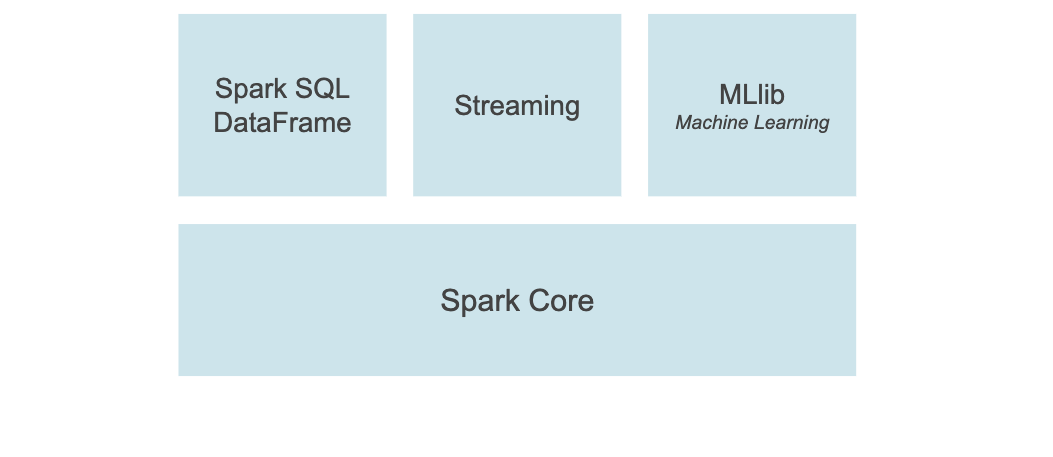

In [1]:
# install pyspark
!pip install pyspark

In [2]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark

In [3]:
# create spark session
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('YbiFoundation').getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/06 17:05:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
# import csv file from github as pandas dataframe and then converting to spark dataframe

df = pd.read_csv('https://github.com/YBIFoundation/BigData/raw/main/HR50k.csv')
df = spark.createDataFrame(df)

In [5]:
# Print/Display the dataframe
df.show()

26/05/06 17:06:09 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---+---------+-----------------+---------+--------------------+----------------+---------+----------------+-------------+--------------+-----------------------+------+----------+--------------+--------+--------------------+---------------+-------------+-------------+-----------+------------------+------+--------+-----------------+-----------------+------------------------+-------------+----------------+-----------------+---------------------+---------------+--------------+------------------+-----------------------+--------------------+
|Age|Attrition|   BusinessTravel|DailyRate|          Department|DistanceFromHome|Education|  EducationField|EmployeeCount|EmployeeNumber|EnvironmentSatisfaction|Gender|HourlyRate|JobInvolvement|JobLevel|             JobRole|JobSatisfaction|MaritalStatus|MonthlyIncome|MonthlyRate|NumCompaniesWorked|Over18|OverTime|PercentSalaryHike|PerformanceRating|RelationshipSatisfaction|StandardHours|StockOptionLevel|TotalWorkingYears|TrainingTimesLastYear|WorkLifeBa

In [6]:
# Show the first row
df.show(1, vertical=True)

-RECORD 0------------------------------
 Age                      | 31         
 Attrition                | No         
 BusinessTravel           | Non-Travel 
 DailyRate                | 158        
 Department               | Software   
 DistanceFromHome         | 7          
 Education                | 3          
 EducationField           | Medical    
 EmployeeCount            | 1          
 EmployeeNumber           | 1          
 EnvironmentSatisfaction  | 3          
 Gender                   | Male       
 HourlyRate               | 42         
 JobInvolvement           | 2          
 JobLevel                 | 3          
 JobRole                  | Developer  
 JobSatisfaction          | 1          
 MaritalStatus            | Married    
 MonthlyIncome            | 42682      
 MonthlyRate              | 298774     
 NumCompaniesWorked       | 2          
 Over18                   | Y          
 OverTime                 | No         
 PercentSalaryHike        | 20         


In [7]:
df.columns

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [8]:
df.printSchema()

root
 |-- Age: long (nullable = true)
 |-- Attrition: string (nullable = true)
 |-- BusinessTravel: string (nullable = true)
 |-- DailyRate: long (nullable = true)
 |-- Department: string (nullable = true)
 |-- DistanceFromHome: long (nullable = true)
 |-- Education: long (nullable = true)
 |-- EducationField: string (nullable = true)
 |-- EmployeeCount: long (nullable = true)
 |-- EmployeeNumber: long (nullable = true)
 |-- EnvironmentSatisfaction: long (nullable = true)
 |-- Gender: string (nullable = true)
 |-- HourlyRate: long (nullable = true)
 |-- JobInvolvement: long (nullable = true)
 |-- JobLevel: long (nullable = true)
 |-- JobRole: string (nullable = true)
 |-- JobSatisfaction: long (nullable = true)
 |-- MaritalStatus: string (nullable = true)
 |-- MonthlyIncome: long (nullable = true)
 |-- MonthlyRate: long (nullable = true)
 |-- NumCompaniesWorked: long (nullable = true)
 |-- Over18: string (nullable = true)
 |-- OverTime: string (nullable = true)
 |-- PercentSalaryHike: 

In [9]:
df.describe().show()

26/05/06 17:06:14 WARN TaskSetManager: Stage 2 contains a task of very large size (1023 KiB). The maximum recommended task size is 1000 KiB.


+-------+------------------+---------+--------------+------------------+----------+------------------+-----------------+----------------+-------------+-----------------+-----------------------+------+---------------+------------------+-----------------+--------------------+------------------+-------------+------------------+------------------+------------------+------+--------+------------------+------------------+------------------------+-------------+------------------+------------------+---------------------+------------------+-----------------+------------------+-----------------------+--------------------+
|summary|               Age|Attrition|BusinessTravel|         DailyRate|Department|  DistanceFromHome|        Education|  EducationField|EmployeeCount|   EmployeeNumber|EnvironmentSatisfaction|Gender|     HourlyRate|    JobInvolvement|         JobLevel|             JobRole|   JobSatisfaction|MaritalStatus|     MonthlyIncome|       MonthlyRate|NumCompaniesWorked|Over18|OverTime| 

In [10]:
spark.conf.set('spark.sql.repl.eagerEval.enabled', True)
df

Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
31,No,Non-Travel,158,Software,7,3,Medical,1,1,3,Male,42,2,3,Developer,1,Married,42682,298774,2,Y,No,20,4,1,80,2,15,1,2,12,4,10,11
38,No,Travel_Rarely,985,Human Resources,33,5,Life Sciences,1,2,1,Female,66,2,4,Healthcare Repres...,3,Single,45252,45252,8,Y,No,2,1,3,80,4,5,4,3,1,1,1,1
59,Yes,Non-Travel,1273,Sales,5,2,Technical Degree,1,3,4,Female,96,1,3,Manufacturing Dir...,2,Married,46149,507639,7,Y,Yes,39,3,2,80,2,9,5,1,6,6,4,3
52,Yes,Travel_Rarely,480,Support,2,5,Marketing,1,4,4,Female,71,2,4,Human Resources,1,Married,27150,27150,4,Y,No,16,3,2,80,2,22,4,4,10,9,5,6
32,No,Non-Travel,543,Human Resources,7,5,Human Resources,1,5,2,Male,122,3,3,Manager,2,Divorced,15894,47682,6,Y,Yes,42,3,4,80,2,30,3,4,29,27,9,7
19,Yes,Non-Travel,779,Hardware,43,1,Medical,1,6,2,Female,195,4,3,Research Director,3,Married,41552,1246560,3,Y,Yes,15,4,3,80,1,33,4,2,16,4,14,3
42,Yes,Non-Travel,934,Support,26,4,Human Resources,1,7,2,Female,80,3,5,Sales Executive,4,Divorced,5303,148484,3,Y,No,45,4,1,80,1,4,3,4,2,1,1,2
30,No,Travel_Rarely,380,Support,19,3,Marketing,1,8,4,Male,165,1,4,Human Resources,4,Single,28555,571100,2,Y,Yes,35,3,2,80,1,2,2,2,2,2,2,2
41,No,Travel_Frequently,1464,Software,16,1,Life Sciences,1,9,3,Male,134,1,2,Manager,4,Divorced,3241,87507,7,Y,No,1,1,3,80,2,8,1,2,2,1,2,2
45,No,Travel_Frequently,1020,Human Resources,17,5,Life Sciences,1,10,4,Female,137,2,4,Manager,2,Married,4323,116721,4,Y,Yes,32,1,3,80,4,6,4,4,5,3,4,1


In [11]:
df.describe().show(vertical=True)

26/05/06 17:06:23 WARN TaskSetManager: Stage 7 contains a task of very large size (1023 KiB). The maximum recommended task size is 1000 KiB.


-RECORD 0----------------------------------------
 summary                  | count                
 Age                      | 50000                
 Attrition                | 50000                
 BusinessTravel           | 50000                
 DailyRate                | 50000                
 Department               | 50000                
 DistanceFromHome         | 50000                
 Education                | 50000                
 EducationField           | 50000                
 EmployeeCount            | 50000                
 EmployeeNumber           | 50000                
 EnvironmentSatisfaction  | 50000                
 Gender                   | 50000                
 HourlyRate               | 50000                
 JobInvolvement           | 50000                
 JobLevel                 | 50000                
 JobRole                  | 50000                
 JobSatisfaction          | 50000                
 MaritalStatus            | 50000                
